## **4° Module**: TT - Feature Selection & Angular Scaling
* September 23°, 2026
#### ESCOM - IPN:

#### *B.S. in Computer Science*
> Miguel Alexander Sanchez Garcia

#### **0° Introduction**

Module 4 turns the 67 radiomic features of each lesion into the vector that every
experimental condition receives, $\mathbf{x} \in [0, \pi]^{12}$, one qubit per feature.
Masses and calcifications are processed separately throughout (D-005).

Two steps, both fitted **only on the training split**, so that nothing learned here has
seen the official test set:

1. **Selection** of 12 features ($k = 12$, D-013) by the ANOVA F-test (D-001). Module 3
   found that, taken as they are, the top 12 contain exact duplicates and near-copies
   (H-024). The selection therefore skips any feature with $|r| > 0.95$ against one already
   chosen (D-024).
2. **Angular scaling** to $[0, \pi]$ (D-004) by a **quantile transform** (D-025), which
   replaced the original min-max scaling after H-028. Each feature becomes a rotation angle
   in the feature map. Qiskit writes each feature as a phase of $2x$, so on $[0, \pi]$ the
   single-qubit phase covers exactly one full turn, $[0, 2\pi]$. On $[0, 2\pi]$ it would turn
   twice, and every pair of values $x$ and $x + \pi$ would receive the same single-qubit
   phase. Only the endpoints $0$ and $\pi$ share it on $[0, \pi]$, and the pairwise terms
   $(\pi - x_i)(\pi - x_j)$ still tell them apart.

A third step prepares Module 6: the **cross-validation folds** of D-018, frozen here so
that every condition is evaluated on exactly the same partition.

> **Why not PCA here (D-001).** PCA would add a linear transformation to the quantum
> conditions that the raw baseline C1 does not have, so a difference between conditions
> could come from that step rather than from the encoding. Selection keeps the original,
> interpretable features.

#### **1° Setup**

**a.** Import the necessary libraries

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import MinMaxScaler, QuantileTransformer
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold

warnings.filterwarnings("ignore")
print("Environment:")
print(f"  scikit-learn : {sklearn.__version__}")
print(f"  numpy        : {np.__version__}")
print(f"  pandas       : {pd.__version__}")

Environment:
  scikit-learn : 1.7.2
  numpy        : 2.2.6
  pandas       : 2.3.3


**b.** Configuration

In [2]:
SEED = 42
DATA_DIR = Path("/Users/alexander_san/TT/Data")
IN_DIR = DATA_DIR / "processed" / "m3"
OUT_DIR = DATA_DIR / "processed" / "m4"          # not versioned, like the rest of Data/
RESULTS_DIR = Path("/Users/alexander_san/TT/Code/results")
FIG_DIR = Path("/Users/alexander_san/TT/Docs/Figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

K = 12                     # qubits (D-013)
R_MAX = 0.95               # redundancy threshold (D-024)
N_FOLDS = 5                # D-018
N_SEED_CANDIDATES = 200    # fold seed chosen by class balance (D-026)
FINDINGS = ["mass", "calcification"]

data = {ft: pd.read_parquet(IN_DIR / f"features_{ft}_raw.parquet") for ft in FINDINGS}
FEATURES = [c for c in data["mass"].columns if c.startswith("original_")]
family_of = lambda f: f.split("_")[1]
short = lambda f: f.replace("original_", "")
for ft, d in data.items():
    print(f"{ft:13s}: {len(d)} lesions ({(d.split == 'train').sum()} train, {(d.split == 'test').sum()} test), "
          f"{len(FEATURES)} features, {(d.crop_check == 'discordant').sum()} flagged discordant (kept, H-020)")

mass         : 1696 lesions (1318 train, 378 test), 67 features, 7 flagged discordant (kept, H-020)
calcification: 1872 lesions (1546 train, 326 test), 67 features, 0 flagged discordant (kept, H-020)


#### **2° The splits: leakage check**

The official CBIS-DDSM split is kept as is (RNF-03). The unit of analysis is the lesion
(D-011), but a patient can have several lesions (2.28 on average, H-008), so the relevant
leak is a **patient** present on both sides. H-005 found none within each subset, and 31
if masses and calcifications were pooled; the check is repeated on the final data.

In [3]:
pats = {}
for ft, d in data.items():
    tr, te = set(d[d.split == "train"].patient_id), set(d[d.split == "test"].patient_id)
    pats[ft] = (tr, te)
    print(f"{ft:13s}: {len(tr)} train patients, {len(te)} test patients, shared: {len(tr & te)}")
all_tr = pats["mass"][0] | pats["calcification"][0]
all_te = pats["mass"][1] | pats["calcification"][1]
print(f"{'pooled':13s}: shared: {len(all_tr & all_te)}  (why the subsets are never mixed, D-005)")

mass         : 691 train patients, 201 test patients, shared: 0
calcification: 602 train patients, 151 test patients, shared: 0
pooled       : shared: 31  (why the subsets are never mixed, D-005)


#### **3° Selection**

**a.** The score

`f_classif` computes, for each feature, the one-way ANOVA $F$ between the two classes on
the training split. For two classes $F = t^2$, so ranking by $F$ is ranking by $|d|$
(Module 3, H-023). A feature is kept or discarded on its own merit, one at a time: the
F-test does not see redundancy between features, which is why the filter below is needed.

In [4]:
scores = {}
for ft, d in data.items():
    tr = d[d.split == "train"]
    F, p = f_classif(tr[FEATURES].values, tr.label.values)
    scores[ft] = (pd.DataFrame({"feature": FEATURES, "family": [family_of(f) for f in FEATURES], "F": F, "p": p})
                  .sort_values(["F", "feature"], ascending=[False, True]).reset_index(drop=True))
    scores[ft]["rank_F"] = np.arange(1, len(FEATURES) + 1)
    print(f"== {ft}: 5 highest F")
    print(scores[ft].head(5).assign(feature=lambda x: x.feature.map(short))[["rank_F", "feature", "F", "p"]]
          .to_string(index=False, float_format=lambda v: f"{v:.3g}"))

== mass: 5 highest F
 rank_F                 feature    F        p
      1      firstorder_Maximum 83.1 2.84e-19
      2 firstorder_90Percentile 82.6 3.61e-19
      3       firstorder_Energy 74.7 1.56e-17
      4  firstorder_TotalEnergy 74.7 1.56e-17
      5 shape2D_MinorAxisLength 66.7 7.23e-16
== calcification: 5 highest F
 rank_F                 feature   F        p
      1 shape2D_MinorAxisLength 235 1.49e-49
      2        glrlm_RunEntropy 201 5.68e-43
      3       shape2D_Perimeter 177 2.59e-38
      4               glcm_Imc1 177  3.2e-38
      5     firstorder_Skewness 175 7.51e-38


**b.** Selection with a redundancy constraint (D-024)

Walk down the F ranking and accept a feature only if its absolute Pearson correlation with
every feature already accepted is at most `R_MAX`, until 12 are accepted. Correlations are
computed on the training split only. Without the constraint (`r_max = ∞`) this is exactly `SelectKBest(k=12)`.

In [5]:
def select(ft, r_max, k=K):
    tr = data[ft][data[ft].split == "train"]
    C = tr[FEATURES].corr().abs()
    chosen, skipped = [], []
    for f in scores[ft].feature:
        clash = [(s, C.loc[f, s]) for s in chosen if C.loc[f, s] > r_max]
        if clash:
            s, r = max(clash, key=lambda c: c[1])
            skipped.append(dict(feature=f, redundant_with=s, abs_r=r))
        else:
            chosen.append(f)
        if len(chosen) == k:
            break
    return chosen, pd.DataFrame(skipped), C


def describe(ft, chosen, C):
    sc = scores[ft].set_index("feature").loc[chosen]
    sub = C.loc[chosen, chosen].values
    off = sub[~np.eye(len(chosen), dtype=bool)]
    fam = sc.family.value_counts().reindex(["firstorder", "shape2D", "glcm", "glrlm"], fill_value=0)
    return dict(**{f"n_{k}": v for k, v in fam.items()}, mean_abs_r=off.mean(), max_abs_r=off.max(),
                pairs_above_095=int((off > 0.95).sum() / 2), worst_rank_F=int(sc.rank_F.max()))


selection, skipped_all, corr = {}, [], {}
rows = []
for ft in FINDINGS:
    plain, _, C = select(ft, r_max=np.inf)
    chosen, skipped, _ = select(ft, r_max=R_MAX)
    selection[ft], corr[ft] = chosen, C
    skipped_all.append(skipped.assign(finding_type=ft))
    rows += [dict(finding_type=ft, selection="SelectKBest as is", **describe(ft, plain, C)),
             dict(finding_type=ft, selection=f"with |r| <= {R_MAX}", **describe(ft, chosen, C))]
comparison = pd.DataFrame(rows)
print(comparison.round(3).to_string(index=False))

 finding_type         selection  n_firstorder  n_shape2D  n_glcm  n_glrlm  mean_abs_r  max_abs_r  pairs_above_095  worst_rank_F
         mass SelectKBest as is             7          5       0        0       0.613      1.000                8            12
         mass  with |r| <= 0.95             4          5       1        2       0.500      0.940                0            19
calcification SelectKBest as is             1          2       4        5       0.576      1.000                5            12
calcification  with |r| <= 0.95             2          3       4        3       0.497      0.943                0            20


In [6]:
for ft in FINDINGS:
    sc = scores[ft].set_index("feature")
    print(f"== {ft}: the 12 selected features, in F order")
    t = sc.loc[selection[ft], ["rank_F", "family", "F"]].reset_index()
    print(t.assign(feature=t.feature.map(short)).to_string(index=False, float_format=lambda v: f"{v:.1f}"))
    s = skipped_all[FINDINGS.index(ft)]
    if len(s):
        print(f"\n   skipped on the way ({len(s)}):")
        print(s.assign(feature=s.feature.map(short), redundant_with=s.redundant_with.map(short))
              [["feature", "redundant_with", "abs_r"]].to_string(index=False, float_format=lambda v: f"{v:.4f}"))
    print()

== mass: the 12 selected features, in F order
                      feature  rank_F     family    F
           firstorder_Maximum       1 firstorder 83.1
      firstorder_90Percentile       2 firstorder 82.6
            firstorder_Energy       3 firstorder 74.7
      shape2D_MinorAxisLength       5    shape2D 66.7
      shape2D_MaximumDiameter       8    shape2D 62.3
            shape2D_Perimeter      11    shape2D 53.1
          shape2D_MeshSurface      12    shape2D 52.8
shape2D_PerimeterSurfaceRatio      14    shape2D 51.3
 glrlm_GrayLevelNonUniformity      15      glrlm 37.8
      firstorder_10Percentile      16 firstorder 31.7
             glcm_Correlation      17       glcm 31.0
 glrlm_RunLengthNonUniformity      19      glrlm 28.8

   skipped on the way (7):
                   feature          redundant_with  abs_r
    firstorder_TotalEnergy       firstorder_Energy 1.0000
         firstorder_Median firstorder_90Percentile 0.9586
firstorder_RootMeanSquared firstorder_90Percentile

**c.** Sensitivity to the threshold

The threshold is a choice, so its consequences are shown for neighbouring values. What
matters is whether the conclusion about families is stable.

In [7]:
sens = []
for ft in FINDINGS:
    for r in (np.inf, 0.99, 0.95, 0.90, 0.80):
        ch, _, C = select(ft, r_max=r)
        sens.append(dict(finding_type=ft, r_max=r, **describe(ft, ch, C)))
sens = pd.DataFrame(sens)
sens.to_csv(RESULTS_DIR / "4_sensibilidad_umbral.csv", index=False)
print(sens.round(3).to_string(index=False))

 finding_type  r_max  n_firstorder  n_shape2D  n_glcm  n_glrlm  mean_abs_r  max_abs_r  pairs_above_095  worst_rank_F
         mass    inf             7          5       0        0       0.613      1.000                8            12
         mass   0.99             5          5       1        1       0.503      0.959                1            17
         mass   0.95             4          5       1        2       0.500      0.940                0            19
         mass   0.90             4          3       3        2       0.431      0.891                0            25
         mass   0.80             5          2       3        2       0.349      0.770                0            35
calcification    inf             1          2       4        5       0.576      1.000                5            12
calcification   0.99             1          3       3        5       0.581      0.980                5            13
calcification   0.95             2          3       4        3  

#### **4° Angular scaling**

**a.** Why not min-max

The first version of this module used `MinMaxScaler(feature_range=(0, π))`. Min-max has a
known weakness: in a heavy-tailed feature, a few extreme values set the range and most
lesions end up in a narrow band of angles (H-028). The features that grow with lesion
area are exactly like that. For those qubits the rotation would be almost the same for
every lesion, which handicaps the angle encoding (C4, C5) and the RBF kernel (C3), but
barely affects the classical MLP (C1). The comparison would then be tilted by the
scaling and not by the encoding.

**b.** The quantile transform (D-025)

Each feature is passed through its **empirical cumulative distribution function** on the
training split, $\hat{F}(x) = $ fraction of training lesions with a value $\le x$, and
multiplied by $\pi$:

$$\theta = \pi\,\hat{F}(x) \in [0, \pi].$$

This is the probability integral transform: if $x$ follows the training distribution,
$\hat{F}(x)$ is uniform on $[0, 1]$. Consequences:

- Every feature uses the whole range $[0, \pi]$ **uniformly**, however skewed it was.
- The transform is monotone, so it preserves the **order** of the lesions. It discards
  the distances within a feature: a lesion twice as large as another is not placed twice
  as far. That is the price of robustness to the tails.
- A test value outside the training range maps to $0$ or $\pi$, the equivalent of
  clipping.
- All five conditions receive the same $\mathbf{x}$ (D-001), so none is favoured.

Min-max is still computed below, only to show the difference.

In [8]:
iqr = lambda v: float(np.subtract(*np.percentile(v, [75, 25])))
scaled, transformers, scale_rows = {}, {}, []
for ft in FINDINGS:
    d = data[ft]
    cols = selection[ft]
    is_tr = (d.split == "train").values
    tr = d[is_tr]
    qt = QuantileTransformer(n_quantiles=min(1000, len(tr)), output_distribution="uniform",
                             subsample=10**9, random_state=SEED).fit(tr[cols].values)
    mm = MinMaxScaler(feature_range=(0, np.pi), clip=True).fit(tr[cols].values)   # comparison only
    X, Xmm = np.pi * qt.transform(d[cols].values), mm.transform(d[cols].values)
    transformers[ft], scaled[ft] = qt, X
    te_raw = d.loc[~is_tr, cols].values
    for j, f in enumerate(cols):
        scale_rows.append(dict(finding_type=ft, order=j + 1, feature=f, family=family_of(f),
                               angle_median=float(np.median(X[is_tr, j])), angle_iqr=iqr(X[is_tr, j]),
                               angle_median_minmax=float(np.median(Xmm[is_tr, j])), angle_iqr_minmax=iqr(Xmm[is_tr, j]),
                               test_below_train_min=float((te_raw[:, j] < tr[f].min()).mean()),
                               test_above_train_max=float((te_raw[:, j] > tr[f].max()).mean())))
scale_df = pd.DataFrame(scale_rows)
print(f"Interquartile range of the angles on train (a uniform distribution on [0, π] gives π/2 = {np.pi / 2:.3f})")
print(scale_df.assign(feature=scale_df.feature.map(short))
      [["finding_type", "order", "feature", "angle_iqr_minmax", "angle_iqr", "test_below_train_min", "test_above_train_max"]]
      .to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print(f"\nAll angles within [0, π]: {all((X.min() >= 0) and (X.max() <= np.pi + 1e-12) for X in scaled.values())}")

Interquartile range of the angles on train (a uniform distribution on [0, π] gives π/2 = 1.571)
 finding_type  order                            feature  angle_iqr_minmax  angle_iqr  test_below_train_min  test_above_train_max
         mass      1                 firstorder_Maximum             0.652      1.569                 0.000                 0.000
         mass      2            firstorder_90Percentile             0.639      1.571                 0.000                 0.000
         mass      3                  firstorder_Energy             0.197      1.570                 0.000                 0.000
         mass      4            shape2D_MinorAxisLength             0.339      1.572                 0.000                 0.000
         mass      5            shape2D_MaximumDiameter             0.386      1.571                 0.000                 0.000
         mass      6                  shape2D_Perimeter             0.317      1.571                 0.000                 0.000
 

#### **5° Cross-validation folds (D-018)**

D-018 fixes a stratified 5-fold cross-validation on the training split and adds a rule:
if a patient ends up split across folds, switch to `StratifiedGroupKFold` grouped by
`patient_id`. Otherwise, a patient's lesions could sit in the training and validation
folds at once, the same leak the official split avoids.

Grouping has a cost. A patient cannot be divided, and some calcification patients have up
to 24 lesions of the same class, so the class balance of the folds depends heavily on the
seed. The seed of the folds is therefore **chosen by balance** (D-026). Among
`N_SEED_CANDIDATES` seeds, the one with the smallest maximum deviation of the malignant
share from the overall share is kept, with ties going to the smallest seed. The criterion
looks only at the labels, never at features or performance, so it cannot tune the result.
The project seed 42 is shown for comparison.

In [9]:
def group_folds(tr, seed):
    y, g = tr.label.values, tr.patient_id.values
    fold = np.empty(len(tr), int)
    for k, (_, va) in enumerate(StratifiedGroupKFold(N_FOLDS, shuffle=True, random_state=seed).split(tr, y, g)):
        fold[va] = k
    return fold


def max_dev(tr, fold):
    y = tr.label.values
    return float(np.abs(pd.Series(y).groupby(fold).mean() - y.mean()).max())


folds, fold_seed, fold_rows, seed_rows = {}, {}, [], []
for ft in FINDINGS:
    tr = data[ft][data[ft].split == "train"].reset_index(drop=True)
    y, g = tr.label.values, tr.patient_id.values
    plain = np.empty(len(tr), int)
    for k, (_, va) in enumerate(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED).split(tr, y)):
        plain[va] = k
    split_pat = int((pd.Series(plain).groupby(g).nunique() > 1).sum())
    devs = pd.Series({sd: max_dev(tr, group_folds(tr, sd)) for sd in range(N_SEED_CANDIDATES)})
    best = int(devs[devs == devs.min()].index.min())
    use = group_folds(tr, best)
    assert (pd.Series(use).groupby(g).nunique() == 1).all()
    folds[ft], fold_seed[ft] = dict(zip(tr.case_id, use)), best
    seed_rows.append(dict(finding_type=ft, patients_split_by_StratifiedKFold=split_pat, patients=len(set(g)),
                          max_dev_seed_42=devs[SEED], max_dev_median=devs.median(), chosen_seed=best, max_dev_chosen=devs[best]))
    for k in range(N_FOLDS):
        m = use == k
        fold_rows.append(dict(finding_type=ft, fold=k, lesions=int(m.sum()), patients=len(set(g[m])),
                              malignant_share=float(y[m].mean())))
seed_df = pd.DataFrame(seed_rows)
fold_df = pd.DataFrame(fold_rows)
fold_df.to_csv(RESULTS_DIR / "4_folds.csv", index=False)
seed_df.to_csv(RESULTS_DIR / "4_semilla_folds.csv", index=False)
print(seed_df.round(3).to_string(index=False))
print()
print(fold_df.pivot(index="fold", columns="finding_type", values=["lesions", "malignant_share"]).round(3).to_string())

 finding_type  patients_split_by_StratifiedKFold  patients  max_dev_seed_42  max_dev_median  chosen_seed  max_dev_chosen
         mass                                410       691            0.038           0.060          125           0.011
calcification                                445       602            0.168           0.065          168           0.019

                   lesions        malignant_share       
finding_type calcification   mass   calcification   mass
fold                                                    
0                    315.0  255.0           0.333  0.486
1                    271.0  258.0           0.354  0.473
2                    322.0  268.0           0.366  0.489
3                    314.0  257.0           0.357  0.494
4                    324.0  280.0           0.349  0.475


**A limitation to declare.** Under Architecture B the embeddings are computed once for the
whole dataset (D-014), so the selector and the scaler are fitted once on the whole
training split, and not inside each fold. The cross-validation estimates are therefore
slightly optimistic, because the selection has seen every fold. The official test split
is untouched and remains the unbiased estimate. Refitting per fold would require
recomputing the embeddings and fidelity kernels five times; whether that is worth it is a
decision for Module 6.

#### **6° Save**

One table per subset with the identifiers, labels, fold (`-1` for test), the flag from
Module 2, and the 12 angles `x_01` … `x_12` in selection order. A JSON file next to it holds
the list of features, the fold seed and the quantiles of the transform, so that the
transformation can be reapplied, by interpolating on the quantiles, or inverted.

In [10]:
for ft in FINDINGS:
    d = data[ft]
    out = d[["case_id", "patient_id", "finding_type", "split", "label", "crop_check"]].copy()
    out["fold"] = out.case_id.map(folds[ft]).fillna(-1).astype(int)
    for j in range(K):
        out[f"x_{j + 1:02d}"] = scaled[ft][:, j]
    out.to_parquet(OUT_DIR / f"x_{ft}.parquet", index=False)
    qt = transformers[ft]
    meta = dict(finding_type=ft, k=K, r_max=R_MAX, seed=SEED, fold_seed=fold_seed[ft],
                scaling="pi * QuantileTransformer(output_distribution='uniform'), fitted on train",
                features=selection[ft], references=qt.references_.tolist(),
                quantiles={f: qt.quantiles_[:, j].tolist() for j, f in enumerate(selection[ft])})
    (OUT_DIR / f"x_{ft}.json").write_text(json.dumps(meta, indent=2))
    print(f"  {(OUT_DIR / f'x_{ft}.parquet').relative_to(DATA_DIR)}: {out.shape}")

sel_table = scale_df.merge(pd.concat([scores[ft].assign(finding_type=ft) for ft in FINDINGS])[["finding_type", "feature", "F", "p", "rank_F"]],
                           on=["finding_type", "feature"])
sel_table.to_csv(RESULTS_DIR / "4_seleccion.csv", index=False)
pd.concat(skipped_all).to_csv(RESULTS_DIR / "4_descartadas_redundancia.csv", index=False)

  processed/m4/x_mass.parquet: (1696, 19)
  processed/m4/x_calcification.parquet: (1872, 19)


#### **7° Visualization**

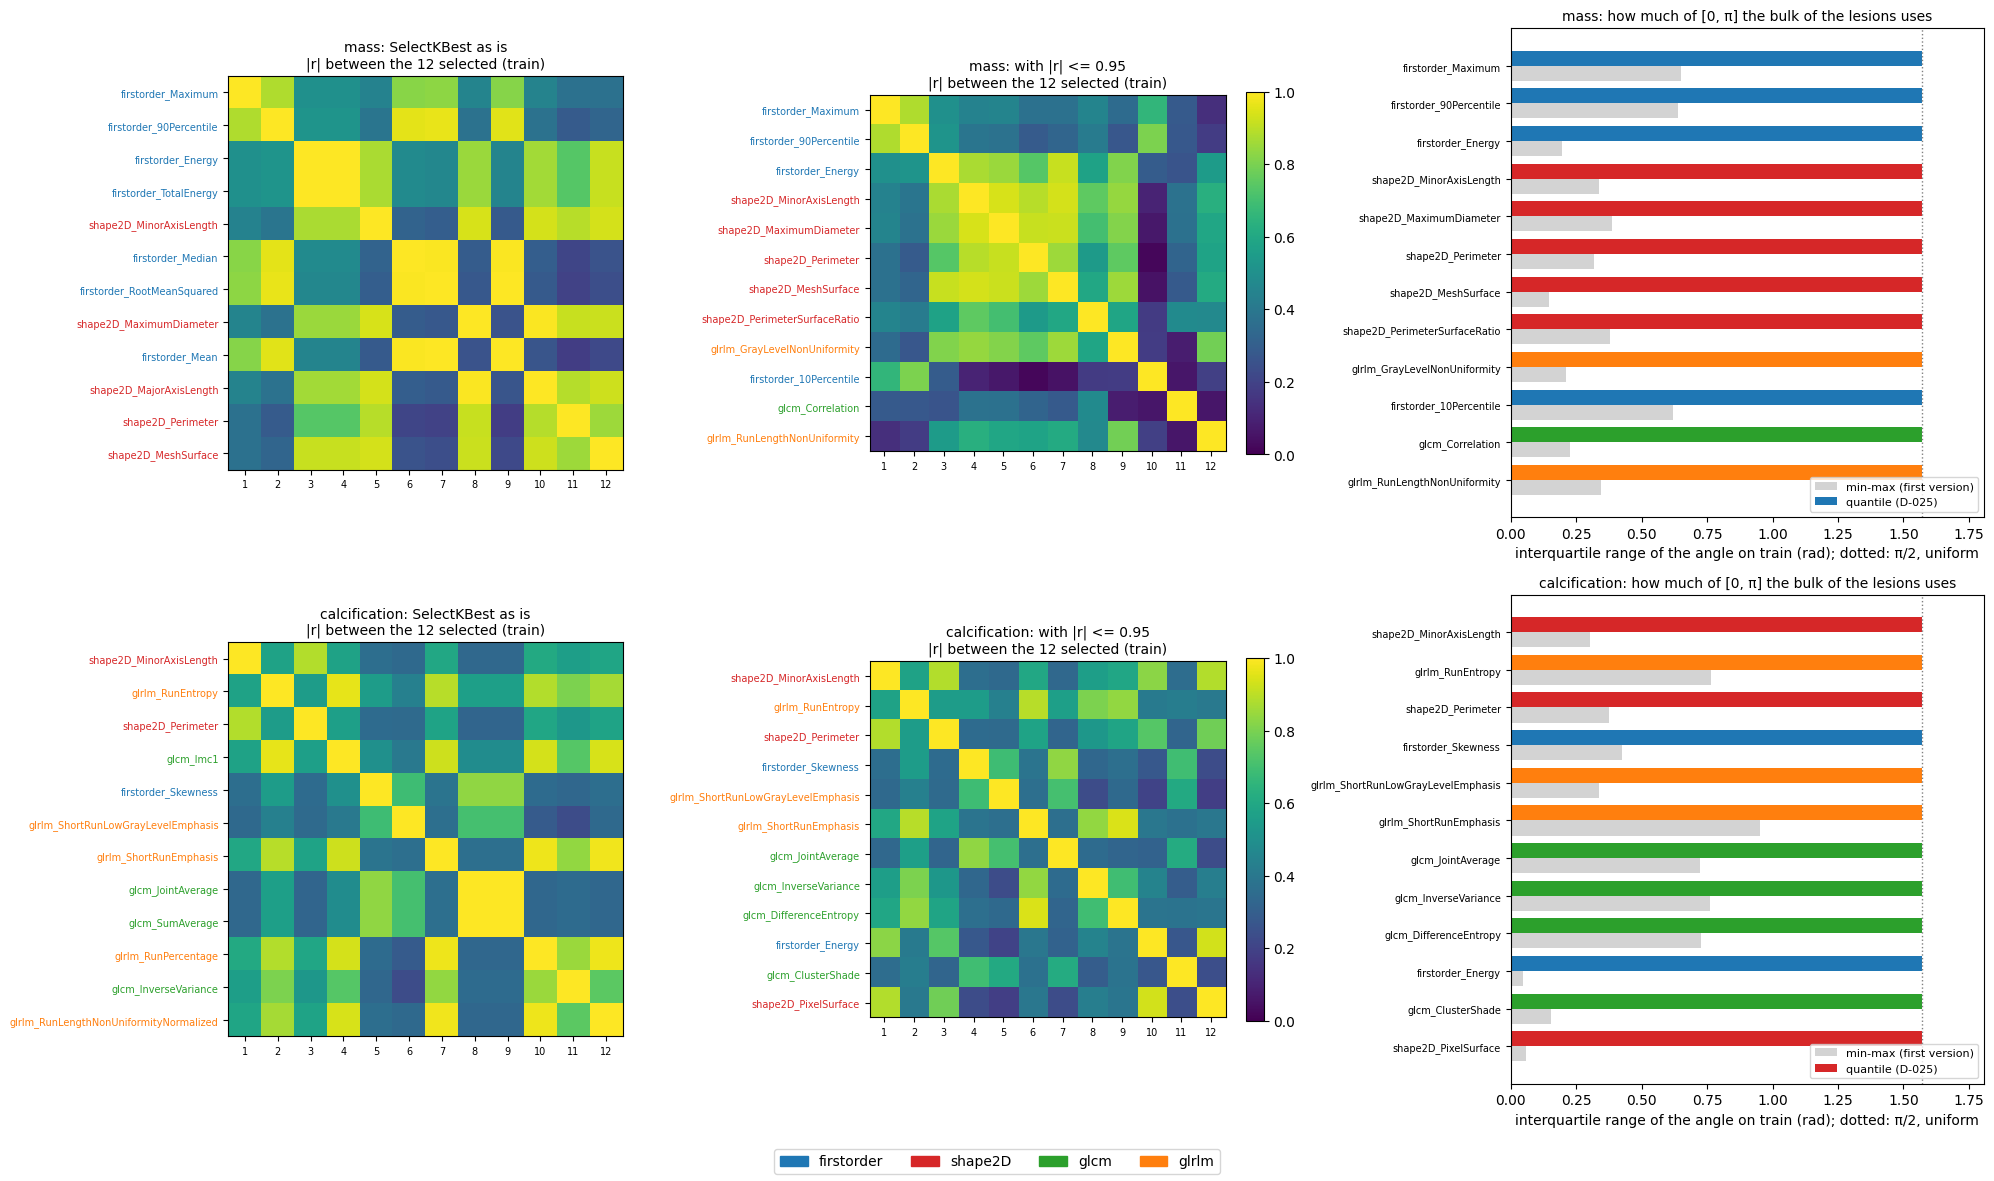

In [11]:
colors = {"firstorder": "C0", "shape2D": "C3", "glcm": "C2", "glrlm": "C1"}
fig, axes = plt.subplots(2, 3, figsize=(20, 12), gridspec_kw=dict(width_ratios=[1, 1, 1.2]))
for row, ft in enumerate(FINDINGS):
    plain, _, C = select(ft, r_max=np.inf)
    for ax, (name, cols) in zip(axes[row, :2], (("SelectKBest as is", plain), (f"with |r| <= {R_MAX}", selection[ft]))):
        im = ax.imshow(C.loc[cols, cols].values, vmin=0, vmax=1, cmap="viridis")
        ax.set_xticks(range(K)); ax.set_yticks(range(K))
        ax.set_yticklabels([short(c) for c in cols], fontsize=7)
        ax.set_xticklabels(range(1, K + 1), fontsize=7)
        for t, c in zip(ax.get_yticklabels(), cols):
            t.set_color(colors[family_of(c)])
        ax.set_title(f"{ft}: {name}\n|r| between the 12 selected (train)", fontsize=10)
    fig.colorbar(im, ax=axes[row, 1], fraction=0.046)
    ax = axes[row, 2]
    s = scale_df[scale_df.finding_type == ft]
    yy = np.arange(K)
    ax.barh(yy + 0.2, s.angle_iqr_minmax, height=0.4, color="lightgray", label="min-max (first version)")
    ax.barh(yy - 0.2, s.angle_iqr, height=0.4, color=[colors[f] for f in s.family], label="quantile (D-025)")
    ax.axvline(np.pi / 2, color="gray", ls=":", lw=1)
    ax.set_yticks(yy); ax.set_yticklabels(s.feature.map(short), fontsize=7); ax.invert_yaxis()
    ax.set_xlim(0, np.pi / 2 * 1.15)
    ax.set_xlabel("interquartile range of the angle on train (rad); dotted: π/2, uniform")
    ax.set_title(f"{ft}: how much of [0, π] the bulk of the lesions uses", fontsize=10)
    ax.legend(fontsize=8, loc="lower right")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
fig.legend(handles, colors.keys(), loc="lower center", ncol=4)
plt.tight_layout(rect=(0, 0.03, 1, 1))
plt.savefig(FIG_DIR / "M4_selection_and_angles.png", dpi=150, bbox_inches="tight")
plt.show()

**Consequence**

**Selection.**
- The redundancy constraint removes the three exact duplicates (`TotalEnergy`,
  `SumAverage`, and `PixelSurface` or `MeshSurface`) and the near-copies. It lowers the mean
  $|r|$ among the twelve from about $0.6$ to $0.50$ and leaves no pair above $0.95$.
- For masses it lets **texture** in: one GLCM and two GLRLM features, where the plain
  selection had none. The cost is going down to rank 19 of the F ranking.
- The conclusion is stable: texture enters at every threshold between $0.99$ and $0.80$.

**Scaling.**
- With min-max, the heavy-tailed features used a sliver of the range, as little as
  $0.05$ rad of interquartile range for `Energy` and `PixelSurface` in calcifications.
- With the quantile transform, every feature has an interquartile range of $\pi/2$, the
  value of a uniform distribution, so no qubit receives a nearly constant rotation.
- Test values outside the training range are rare, at most 0.6 % for one feature, and map
  to the ends of the range.

**Folds.**
- Plain `StratifiedKFold` would have split 59 % of mass patients and 74 % of calcification
  patients across folds, so D-018's own rule applies and the folds are grouped by patient.
- With the seed chosen by balance, the malignant share of every fold stays within $0.011$
  (masses) and $0.019$ (calcifications) of the overall share. Seed 42 gave $0.038$ and
  $0.168$.

#### **8° Summary**

In [12]:
print("=" * 74)
print("MODULE 4 - FEATURE SELECTION & ANGULAR SCALING - SUMMARY")
print("=" * 74)
for ft in FINDINGS:
    a = comparison[(comparison.finding_type == ft) & (comparison.selection == "SelectKBest as is")].iloc[0]
    b = comparison[(comparison.finding_type == ft) & (comparison.selection != "SelectKBest as is")].iloc[0]
    s = scale_df[scale_df.finding_type == ft]
    sd = seed_df[seed_df.finding_type == ft].iloc[0]
    print(f"  {ft}")
    print(f"    SelectKBest as is : {a.n_firstorder} first-order, {a.n_shape2D} shape, {a.n_glcm} GLCM, {a.n_glrlm} GLRLM;"
          f" mean |r| {a.mean_abs_r:.2f}, {a.pairs_above_095} pairs > 0.95")
    print(f"    with |r| <= {R_MAX}   : {b.n_firstorder} first-order, {b.n_shape2D} shape, {b.n_glcm} GLCM, {b.n_glrlm} GLRLM;"
          f" mean |r| {b.mean_abs_r:.2f}, max |r| {b.max_abs_r:.2f}; deepest F rank used {b.worst_rank_F}")
    print(f"    angle IQR (train) : min-max min {s.angle_iqr_minmax.min():.2f} rad -> quantile min {s.angle_iqr.min():.2f} rad (π/2 = {np.pi / 2:.2f})")
    print(f"    folds             : StratifiedGroupKFold, seed {sd.chosen_seed}; max class-share deviation "
          f"{sd.max_dev_chosen:.3f} (seed 42: {sd.max_dev_seed_42:.3f})")
print(f"  Test split untouched; {N_FOLDS} folds on train, no patient split")
print("=" * 74)

MODULE 4 - FEATURE SELECTION & ANGULAR SCALING - SUMMARY
  mass
    SelectKBest as is : 7 first-order, 5 shape, 0 GLCM, 0 GLRLM; mean |r| 0.61, 8 pairs > 0.95
    with |r| <= 0.95   : 4 first-order, 5 shape, 1 GLCM, 2 GLRLM; mean |r| 0.50, max |r| 0.94; deepest F rank used 19
    angle IQR (train) : min-max min 0.14 rad -> quantile min 1.57 rad (π/2 = 1.57)
    folds             : StratifiedGroupKFold, seed 125; max class-share deviation 0.011 (seed 42: 0.038)
  calcification
    SelectKBest as is : 1 first-order, 2 shape, 4 GLCM, 5 GLRLM; mean |r| 0.58, 5 pairs > 0.95
    with |r| <= 0.95   : 2 first-order, 3 shape, 4 GLCM, 3 GLRLM; mean |r| 0.50, max |r| 0.94; deepest F rank used 20
    angle IQR (train) : min-max min 0.05 rad -> quantile min 1.57 rad (π/2 = 1.57)
    folds             : StratifiedGroupKFold, seed 168; max class-share deviation 0.019 (seed 42: 0.168)
  Test split untouched; 5 folds on train, no patient split
